# 📊 Results & Evaluation
**Brain Tumor Detection via MOAOA-FDL**

This notebook trains the LSTM using the best hyperparameters found by MOAOA,
generates all evaluation plots, and saves metrics to CSV.

> **Important:** Run this notebook from the **project root** directory.
> All paths are resolved relative to the working directory.


## 📦 Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, matthews_corrcoef, cohen_kappa_score,
)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import os
import sys
import csv

# Paths — run notebook from the project root directory
BASE = os.path.abspath("")
while BASE != os.path.dirname(BASE):
    if os.path.isdir(os.path.join(BASE, "src")):
        break
    BASE = os.path.dirname(BASE)
if BASE not in sys.path:
    sys.path.insert(0, BASE)
FEATURES_DIR = os.path.join(BASE, "data", "outputs", "features")
OUT_DIR      = os.path.join(BASE, "data", "outputs", "results")
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Results will be saved to: {OUT_DIR}")


Using device: cpu
Results will be saved to: d:\Programming\Opti-Project\Opti-Project\data\outputs\results


## 📂 Load & Prepare Data

In [2]:
x_data = np.load(os.path.join(FEATURES_DIR, "features.npy"))
y_data = np.load(os.path.join(FEATURES_DIR, "labels.npy"))

print(f"Features shape : {x_data.shape}")
print(f"Labels shape   : {y_data.shape}")
print(f"Unique labels  : {np.unique(y_data, return_counts=True)}")

sc     = StandardScaler()
x_data = sc.fit_transform(x_data)

# Split: 70% train / 30% test
x_tr, x_te, y_tr, y_te = train_test_split(
    x_data, y_data, test_size=0.3, random_state=42, stratify=y_data
)
print(f"\nTrain: {x_tr.shape[0]} samples | Test: {x_te.shape[0]} samples")


Features shape : (1260, 1186)
Labels shape   : (1260,)
Unique labels  : (array([0, 1], dtype=int32), array([770, 490]))

Train: 882 samples | Test: 378 samples


## 🧠 LSTM Model Definition

In [3]:
from src.classification.models.lstm import MyLSTM, N_STEPS, H_SIZE

# Prepare tensors
dim = x_tr.shape[1] // N_STEPS

def to_tensor(X, y):
    xt = torch.tensor(X[:, :N_STEPS * dim], dtype=torch.float32) \
               .reshape(-1, N_STEPS, dim).to(device)
    yt = torch.tensor(y, dtype=torch.long).to(device)
    return xt, yt

xtr, ytr = to_tensor(x_tr, y_tr)
xte, yte = to_tensor(x_te, y_te)   # yte = GPU tensor; y_te = NumPy (used for metrics)

print(f"Input dim per step : {dim}")
print(f"Train tensor shape : {xtr.shape}")
print(f"Test  tensor shape : {xte.shape}")


Input dim per step : 593
Train tensor shape : torch.Size([882, 2, 593])
Test  tensor shape : torch.Size([378, 2, 593])


## ⚙️ Hyperparameters

Best params found by the MOAOA optimization run in `src/classification/models/classifier.py`.


In [4]:
LR  = 0.00601250713516592
BS  = 34
EPS = 390

print(f"Learning Rate : {LR}")
print(f"Batch Size    : {BS}")
print(f"Epochs        : {EPS}")


Learning Rate : 0.00601250713516592
Batch Size    : 34
Epochs        : 390


## 🚀 Training Loop

In [5]:
model     = MyLSTM(dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
loader    = DataLoader(TensorDataset(xtr, ytr), batch_size=BS, shuffle=True)

t_loss, t_acc = [], []
v_loss, v_acc = [], []
preds = None  # will hold final test predictions (NumPy array)

print("Training...")
for e in range(1, EPS + 1):
    # --- Train ---
    model.train()
    L, correct, total = 0, 0, 0
    for xb, yb in loader:
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        L       += loss.item()
        correct += (torch.argmax(out, 1) == yb).sum().item()
        total   += yb.size(0)

    t_loss.append(L / len(loader))
    t_acc.append(correct / total)

    # --- Validate ---
    model.eval()
    with torch.no_grad():
        out_v = model(xte)
        v_l   = criterion(out_v, yte).item()
        preds = torch.argmax(out_v, 1).cpu().numpy()  # NumPy predictions
        v_a   = (preds == y_te).mean()                # compare with NumPy y_te

    v_loss.append(v_l)
    v_acc.append(v_a)

    if e % 20 == 0 or e == EPS:
        print(f"Epoch {e:>4}/{EPS} | Train Loss: {t_loss[-1]:.4f} | Test Acc: {v_a:.4f}")

print("\nTraining complete.")


Training...
Epoch   20/390 | Train Loss: 0.0318 | Test Acc: 0.9365
Epoch   40/390 | Train Loss: 0.0448 | Test Acc: 0.9550
Epoch   60/390 | Train Loss: 0.0164 | Test Acc: 0.9524
Epoch   80/390 | Train Loss: 0.0161 | Test Acc: 0.9497
Epoch  100/390 | Train Loss: 0.0157 | Test Acc: 0.9524
Epoch  120/390 | Train Loss: 0.0421 | Test Acc: 0.9444
Epoch  140/390 | Train Loss: 0.0212 | Test Acc: 0.9630
Epoch  160/390 | Train Loss: 0.0226 | Test Acc: 0.9524
Epoch  180/390 | Train Loss: 0.0048 | Test Acc: 0.9656
Epoch  200/390 | Train Loss: 0.0202 | Test Acc: 0.9471
Epoch  220/390 | Train Loss: 0.0135 | Test Acc: 0.9630
Epoch  240/390 | Train Loss: 0.0133 | Test Acc: 0.9550
Epoch  260/390 | Train Loss: 0.0057 | Test Acc: 0.9550
Epoch  280/390 | Train Loss: 0.0163 | Test Acc: 0.9577
Epoch  300/390 | Train Loss: 0.0094 | Test Acc: 0.9550
Epoch  320/390 | Train Loss: 0.0100 | Test Acc: 0.9656
Epoch  340/390 | Train Loss: 0.0083 | Test Acc: 0.9603
Epoch  360/390 | Train Loss: 0.0115 | Test Acc: 0.970

## 📈 Accuracy & Loss Curves

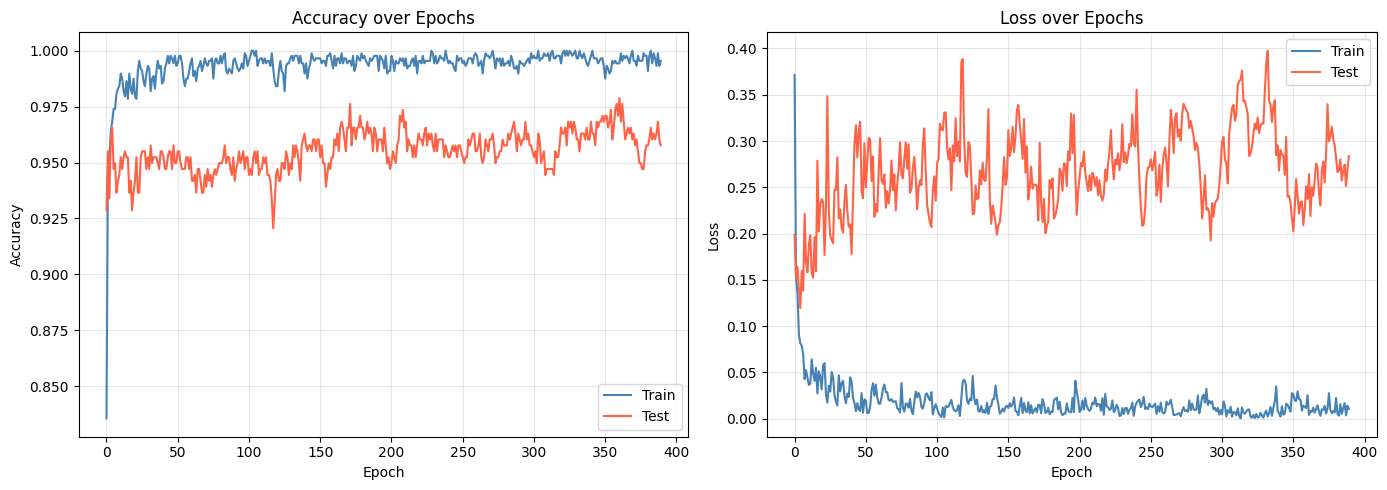

Saved accuracy_curve.png and loss_curve.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t_acc,  label="Train", color="steelblue")
ax1.plot(v_acc,  label="Test",  color="tomato")
ax1.set_title("Accuracy over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(t_loss, label="Train", color="steelblue")
ax2.plot(v_loss, label="Test",  color="tomato")
ax2.set_title("Loss over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "accuracy_curve.png"), dpi=150)
plt.savefig(os.path.join(OUT_DIR, "loss_curve.png"),     dpi=150)
plt.show()
print("Saved accuracy_curve.png and loss_curve.png")


## 🔥 Confusion Matrix

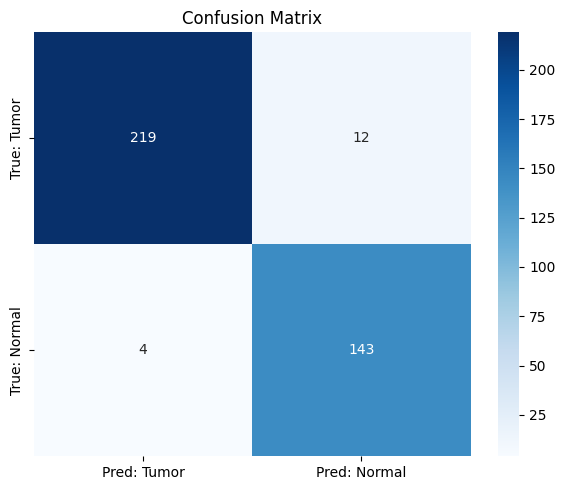

Saved confusion_matrix.png


In [7]:
cm = confusion_matrix(y_te, preds)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: Tumor", "Pred: Normal"],
    yticklabels=["True: Tumor", "True: Normal"],
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print("Saved confusion_matrix.png")


## 📊 Comparison Charts — Sensitivity, Specificity & Accuracy

Accuracy    : 95.77%
Sensitivity : 97.28%
Specificity : 94.81%
F1-Score    : 95.79%
MCC         : 0.9127
Kappa       : 0.9118


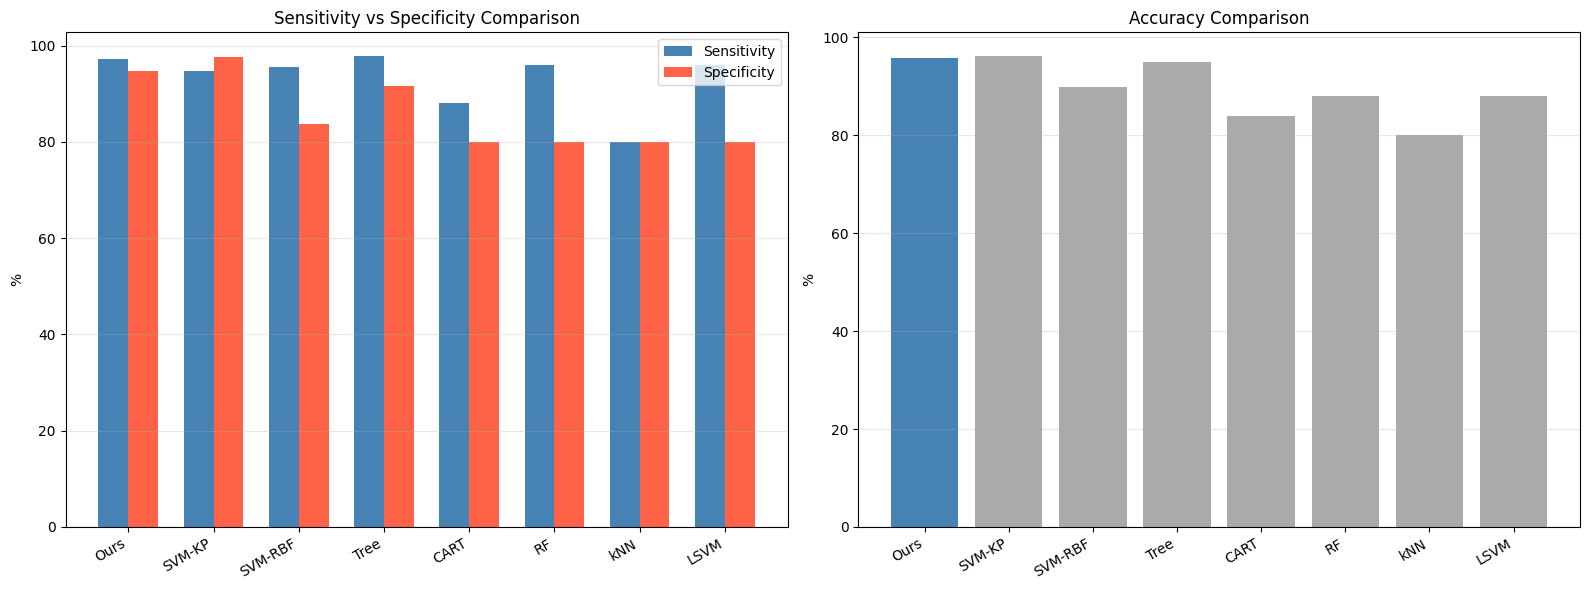

Saved comparison charts.


In [8]:
sens = tp / (tp + fn + 1e-8)
spec = tn / (tn + fp + 1e-8)
f1   = f1_score(y_te, preds, average="weighted")
mcc  = matthews_corrcoef(y_te, preds)
kap  = cohen_kappa_score(y_te, preds)
acc  = (preds == y_te).mean()

print(f"Accuracy    : {acc*100:.2f}%")
print(f"Sensitivity : {sens*100:.2f}%")
print(f"Specificity : {spec*100:.2f}%")
print(f"F1-Score    : {f1*100:.2f}%")
print(f"MCC         : {mcc:.4f}")
print(f"Kappa       : {kap:.4f}")

# Baseline methods from research paper
names     = ["Ours", "SVM-KP", "SVM-RBF", "Tree", "CART", "RF", "kNN", "LSVM"]
sens_vals = [round(sens*100, 2), 94.73, 95.62, 97.88, 88.0, 96.0, 80.0, 96.0]
spec_vals = [round(spec*100, 2), 97.59, 83.71, 91.71, 80.0, 80.0, 80.0, 80.0]
acc_vals  = [round(acc*100,  2), 96.18, 89.88, 94.95, 84.0, 88.0, 80.0, 88.0]

x = np.arange(len(names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x - w/2, sens_vals, w, label="Sensitivity", color="steelblue")
axes[0].bar(x + w/2, spec_vals, w, label="Specificity",  color="tomato")
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha="right")
axes[0].legend()
axes[0].set_title("Sensitivity vs Specificity Comparison")
axes[0].set_ylabel("%")
axes[0].grid(axis="y", alpha=0.3)

colors = ["steelblue"] + ["#aaaaaa"] * (len(names) - 1)
axes[1].bar(x, acc_vals, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=30, ha="right")
axes[1].set_title("Accuracy Comparison")
axes[1].set_ylabel("%")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "sensitivity_specificity.png"), dpi=150)
plt.savefig(os.path.join(OUT_DIR, "accuracy_comparison.png"),     dpi=150)
plt.show()
print("Saved comparison charts.")


## 💾 Save Metrics to CSV

In [9]:
csv_path = os.path.join(OUT_DIR, "metrics.csv")

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Metric",      "Value"])
    writer.writerow(["Accuracy",    f"{acc*100:.2f}%"])
    writer.writerow(["Sensitivity", f"{sens*100:.2f}%"])
    writer.writerow(["Specificity", f"{spec*100:.2f}%"])
    writer.writerow(["F1-Score",    f"{f1*100:.2f}%"])
    writer.writerow(["MCC",         f"{mcc:.4f}"])
    writer.writerow(["Kappa",       f"{kap:.4f}"])

print(f"✅ Metrics saved to: {csv_path}")
print(f"✅ All plots saved to: {OUT_DIR}")
print()
print(classification_report(y_te, preds, target_names=["Tumor", "Normal"]))


✅ Metrics saved to: d:\Programming\Opti-Project\Opti-Project\data\outputs\results\metrics.csv
✅ All plots saved to: d:\Programming\Opti-Project\Opti-Project\data\outputs\results

              precision    recall  f1-score   support

       Tumor       0.98      0.95      0.96       231
      Normal       0.92      0.97      0.95       147

    accuracy                           0.96       378
   macro avg       0.95      0.96      0.96       378
weighted avg       0.96      0.96      0.96       378

